In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (442, 10)
Target shape: (442,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE:", mse_linear)
print("R-squared:", r2_linear)

Linear Regression
MSE: 2900.193628493482
R-squared: 0.4526027629719195


In [7]:
ridge_pipeline = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
ridge_params = {"ridge__alpha": [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression")
print("Best alpha:", ridge_cv.best_params_["ridge__alpha"])
print("MSE:", mse_ridge)
print("R-squared:", r2_ridge)


Ridge Regression
Best alpha: 10
MSE: 2875.7787184218428
R-squared: 0.4572109567780849


In [8]:
lasso_pipeline = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(max_iter=10000))])
lasso_params = {"lasso__alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring="neg_mean_squared_error")
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression")
print("Best alpha:", lasso_cv.best_params_["lasso__alpha"])
print("MSE:", mse_lasso)
print("R-squared:", r2_lasso)


Lasso Regression
Best alpha: 1
MSE: 2824.568094049959
R-squared: 0.46687670944102466


In [9]:
print("\nModel Comparison")
print(f"Linear Regression: MSE = {mse_linear:.2f}, R2 = {r2_linear:.4f}")
print(f"Ridge Regression: MSE = {mse_ridge:.2f}, R2 = {r2_ridge:.4f}")
print(f"Lasso Regression: MSE = {mse_lasso:.2f}, R2 = {r2_lasso:.4f}")


Model Comparison
Linear Regression: MSE = 2900.19, R2 = 0.4526
Ridge Regression: MSE = 2875.78, R2 = 0.4572
Lasso Regression: MSE = 2824.57, R2 = 0.4669


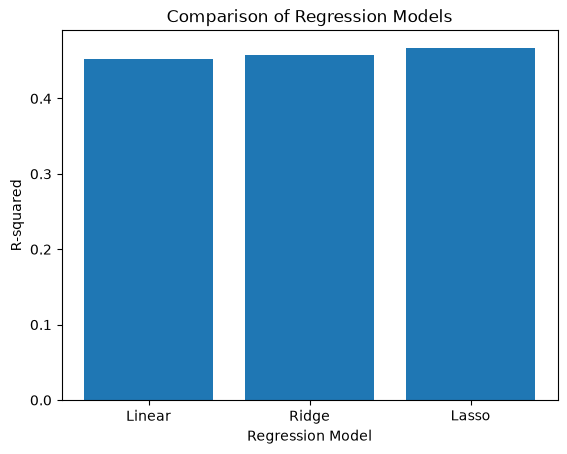

In [10]:
models = ["Linear", "Ridge", "Lasso"]
r2_scores = [r2_linear, r2_ridge, r2_lasso]

plt.bar(models, r2_scores)
plt.xlabel("Regression Model")
plt.ylabel("R-squared")
plt.title("Comparison of Regression Models")
plt.show()

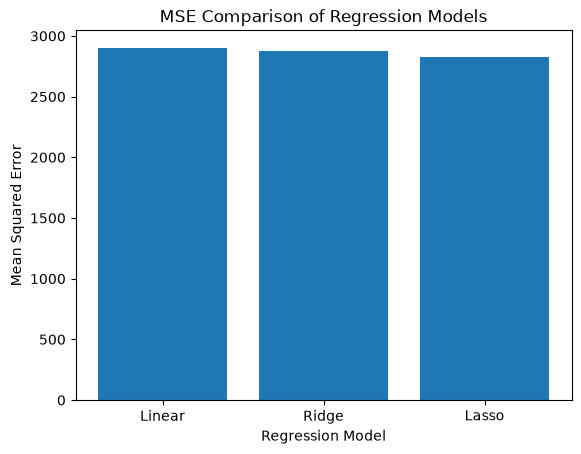

In [11]:
mse_scores = [mse_linear, mse_ridge, mse_lasso]

plt.bar(models, mse_scores)
plt.xlabel("Regression Model")
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison of Regression Models")
plt.show()